<a href="https://colab.research.google.com/github/Lio72rga/Aprendizaje_Automatico-2026/blob/main/Clase3_Lionel_Martinez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Inspeccion inicial del archivo**

In [5]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('Automobile.csv')

# Inspeccionar las primeras filas
print("Primeras 5 filas:")
print(df.head())

# Ver información general (tipos de datos, valores nulos)
print("\nInformación del dataset:")
print(df.info())

Primeras 5 filas:
                        name   mpg  cylinders  displacement  horsepower  \
0  chevrolet chevelle malibu  18.0          8         307.0       130.0   
1          buick skylark 320  15.0          8         350.0       165.0   
2         plymouth satellite  18.0          8         318.0       150.0   
3              amc rebel sst  16.0          8         304.0       150.0   
4                ford torino  17.0          8         302.0       140.0   

   weight  acceleration  model_year origin  
0    3504          12.0          70    usa  
1    3693          11.5          70    usa  
2    3436          11.0          70    usa  
3    3433          12.0          70    usa  
4    3449          10.5          70    usa  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          398 non-null    object 
 1

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Esto es necesario para que el archivo se lea correctamente
df = pd.read_csv('Automobile.csv')

**Limpieza de datos**

In [7]:
# Limpiar filas donde 'horsepower' está vacío
df = df.dropna(subset=['horsepower'])

A continuación, realizaremos un gráfico de dispersión para analizar la correlación entre el peso del vehículo y su consumo.

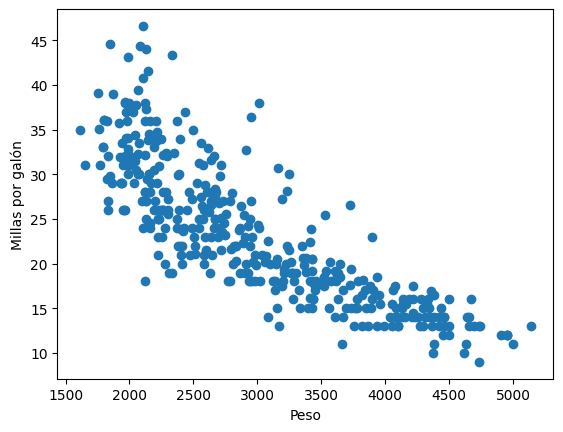

In [8]:
plt.scatter(df['weight'], df['mpg'])
plt.xlabel('Peso')
plt.ylabel('Millas por galón')
plt.show()

* **Interpretación:**

  **Nota** cómo los puntos tienden a bajar desde la izquierda hacia la derecha.

  Esto indica una correlación negativa. A medida que aumenta el peso del auto (weight), las millas por galón (mpg) tienden a disminuir. Es decir, los autos más pesados suelen consumir más combustible.

* **Detección de anomalías:**

   **Análisis de consistencia de los datos**
   
  Tras la visualización de la relación entre el peso del vehículo (weight) y su eficiencia (mpg), se observa una tendencia negativa clara y consistente. Es importante destacar que, en el rango de los datos analizados, no se han detectado valores atípicos (outliers) significativos o puntos que se desvíen drásticamente del patrón general de comportamiento. Esta homogeneidad sugiere que el conjunto de datos es robusto y que la relación entre ambas variables es estable, lo cual es una propiedad favorable para la futura implementación de modelos de aprendizaje automático, ya que reduce el impacto de ruido o anomalías en el entrenamiento.

# **Ajuste Polinomial**

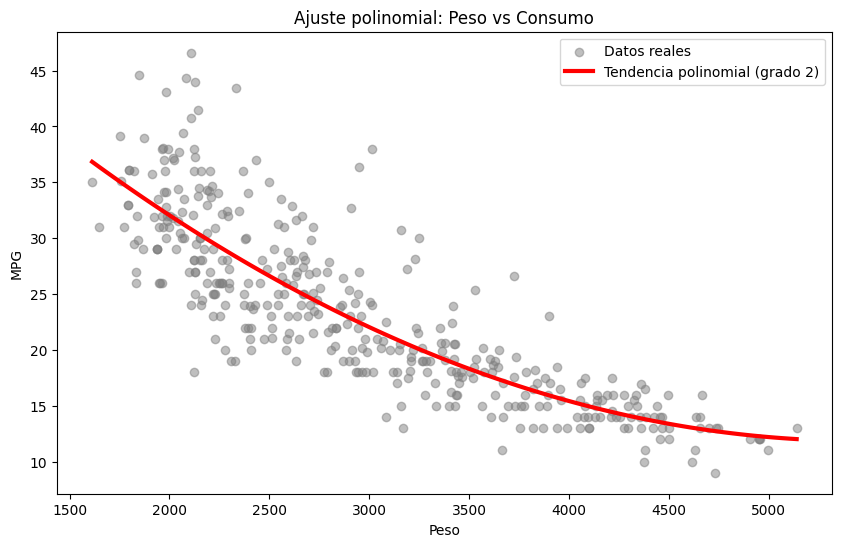

In [9]:
import numpy as np

# 1. Definimos los datos (X=weight, Y=mpg)
x = df['weight']
y = df['mpg']

# 2. Ajustamos un polinomio de grado 2 (una curva)
# np.polyfit calcula los coeficientes, np.poly1d crea la función
coeficientes = np.polyfit(x, y, 2)
polinomio = np.poly1d(coeficientes)

# 3. Creamos puntos para la línea de tendencia
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = polinomio(x_linea)

# 4. Graficamos
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='gray', alpha=0.5, label='Datos reales')
plt.plot(x_linea, y_linea, color='red', linewidth=3, label='Tendencia polinomial (grado 2)')
plt.title('Ajuste polinomial: Peso vs Consumo')
plt.xlabel('Peso')
plt.ylabel('MPG')
plt.legend()
plt.show()

# **Análisis del Ajuste Polinomial**

Para complementar el análisis de correlación lineal, se aplicó un ajuste polinomial de segundo grado sobre la relación entre el peso del vehículo (weight) y su eficiencia en el consumo (mpg).

A diferencia de un modelo lineal, esta curva permite capturar la curvatura presente en los datos, evidenciando que la disminución en la eficiencia del combustible no ocurre de manera constante, sino que presenta una tasa de cambio que se ajusta mejor a una tendencia no lineal. Este tipo de modelado es fundamental en Aprendizaje Automático, ya que proporciona una representación más precisa del comportamiento de los datos y sienta las bases para la implementación de algoritmos de regresión más complejos.

**Nota**
Ese ajuste curvo que vemos en el grafico (la línea roja) es una representación simplificada de la realidad: nos dice que a medida que el auto se vuelve más pesado, la caída en el consumo no es lineal, sino que se acelera o desacelera en ciertos tramos.

# **Mapa de colores**.
 En este caso, vamos a usar los cilindros (cylinders) para colorear los puntos. Esto nos ayudará a ver visualmente cómo la cantidad de cilindros (una variable categórica/discreta) influye en la relación peso-consumo.

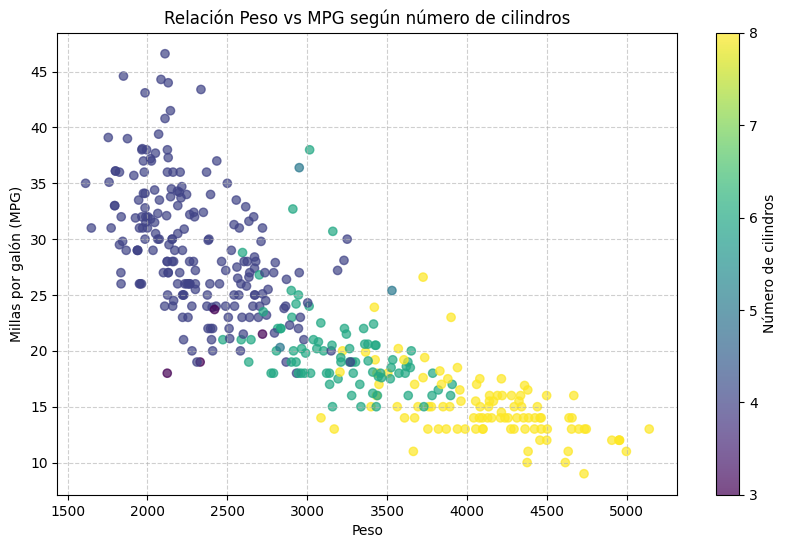

In [10]:
# Crear el gráfico de dispersión con mapa de colores
plt.figure(figsize=(10, 6))

# c=df['cylinders'] define que el color depende de los cilindros
# cmap='viridis' es la paleta de colores
scatter = plt.scatter(df['weight'], df['mpg'], c=df['cylinders'], cmap='viridis', alpha=0.7)

# Añadir barra de color para entender la escala
plt.colorbar(scatter, label='Número de cilindros')

plt.title('Relación Peso vs MPG según número de cilindros')
plt.xlabel('Peso')
plt.ylabel('Millas por galón (MPG)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **Análisis de variables mediante Mapas de Colores**
* Al aplicar una escala de colores basada en la variable cylinders utilizando el mapa viridis (mapa de colores perceptualmente uniforme), se observa una estratificación clara de los datos: los vehículos con mayor número de cilindros (representados por los colores más brillantes/amarillos) se concentran consistentemente en la zona de mayor peso y menor eficiencia de combustible (mpg).
* Por el contrario, los vehículos con menor cantidad de cilindros (colores oscuros/azules) ocupan la región de mayor eficiencia y menor peso.
* Esta visualización confirma que el número de cilindros es una variable predictiva clave para el consumo, y que la relación entre peso y eficiencia está directamente mediada por la arquitectura del motor.